In [ ]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, classification_report,
    precision_recall_curve
)
from sklearn.linear_model import LogisticRegression

# Gradient Boosting
import xgboost as xgb
import lightgbm as lgb

# Encoding
from sklearn.preprocessing import LabelEncoder

# Reproducibility
RANDOM_STATE = 42

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train (6).csv to train (6).csv


In [ ]:
features = pd.read_csv("train (6).csv")

features.head()

,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,Var10,...,Var221,Var222,Var223,Var224,Var225,Var226,Var227,Var228,Var229,Var230
0,NaN,NaN,NaN,NaN,NaN,1526.0,7.0,NaN,NaN,NaN,...,oslk,fXVEsaq,jySVZNlOJy,NaN,NaN,xb3V,RAYp,F2FyR07IdsN7I,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,525.0,0.0,NaN,NaN,NaN,...,oslk,2Kb5FSF,LM8l689qOp,NaN,NaN,fKCe,RAYp,F2FyR07IdsN7I,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,5236.0,7.0,NaN,NaN,NaN,...,Al6ZaUT,NKv4yOc,jySVZNlOJy,NaN,kG3k,Qu4f,02N6s8f,ib5G6X1eUxUn6,am7c,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,...,oslk,CE7uk3u,LM8l689qOp,NaN,NaN,FSa2,RAYp,F2FyR07IdsN7I,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,1029.0,7.0,NaN,NaN,NaN,...,oslk,1J2cvxe,LM8l689qOp,NaN,kG3k,FSa2,RAYp,F2FyR07IdsN7I,mj86,NaN


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train_churn_labels.csv to train_churn_labels.csv


In [ ]:
labels = pd.read_csv("train_churn_labels.csv")

print(features.shape, labels.shape)

(50000, 230) (50000, 1)


In [ ]:
features.reset_index(inplace=True)
labels.reset_index(inplace=True)
features.head()
labels.head()

,index,Label
0,0,-1
1,1,1
2,2,-1
3,3,-1
4,4,-1


In [ ]:
features.columns

Index(['index', 'Var1', 'Var2', 'Var3', 'Var4', 'Var5', 'Var6', 'Var7', 'Var8',
       'Var9',
       ...
       'Var221', 'Var222', 'Var223', 'Var224', 'Var225', 'Var226', 'Var227',
       'Var228', 'Var229', 'Var230'],
      dtype='object', length=231)

In [ ]:
features.rename(columns={"index": "customer_id"}, inplace=True)
labels.rename(columns={"index": "target"}, inplace=True)

In [ ]:
features.head()


,customer_id,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,...,Var221,Var222,Var223,Var224,Var225,Var226,Var227,Var228,Var229,Var230
0,0,NaN,NaN,NaN,NaN,NaN,1526.0,7.0,NaN,NaN,...,oslk,fXVEsaq,jySVZNlOJy,NaN,NaN,xb3V,RAYp,F2FyR07IdsN7I,NaN,NaN
1,1,NaN,NaN,NaN,NaN,NaN,525.0,0.0,NaN,NaN,...,oslk,2Kb5FSF,LM8l689qOp,NaN,NaN,fKCe,RAYp,F2FyR07IdsN7I,NaN,NaN
2,2,NaN,NaN,NaN,NaN,NaN,5236.0,7.0,NaN,NaN,...,Al6ZaUT,NKv4yOc,jySVZNlOJy,NaN,kG3k,Qu4f,02N6s8f,ib5G6X1eUxUn6,am7c,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,...,oslk,CE7uk3u,LM8l689qOp,NaN,NaN,FSa2,RAYp,F2FyR07IdsN7I,NaN,NaN
4,4,NaN,NaN,NaN,NaN,NaN,1029.0,7.0,NaN,NaN,...,oslk,1J2cvxe,LM8l689qOp,NaN,kG3k,FSa2,RAYp,F2FyR07IdsN7I,mj86,NaN


In [ ]:
KEY_COL = "customer_id"
TARGET_COL = "target"

# Validate uniqueness
assert features[KEY_COL].is_unique, "Duplicate keys in features"
assert labels[TARGET_COL].is_unique, "Duplicate keys in labels"

# Join
data = features.merge(labels, left_on = KEY_COL, right_on = TARGET_COL, how="inner")

# Post-join checks
print("Final shape:", data.shape)
print("Target distribution:\n", data[TARGET_COL].value_counts(normalize=True))

Final shape: (50000, 233)
Target distribution:
 target
49983    0.00002
49982    0.00002
49981    0.00002
49980    0.00002
49979    0.00002
          ...   
4        0.00002
3        0.00002
2        0.00002
1        0.00002
0        0.00002
Name: proportion, Length: 50000, dtype: float64


In [ ]:
data.info()
data.describe()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 233 entries, customer_id to Label
dtypes: float64(191), int64(4), object(38)
memory usage: 88.9+ MB


,customer_id,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,...,Var223,Var224,Var225,Var226,Var227,Var228,Var229,Var230,target,Label
0,0,NaN,NaN,NaN,NaN,NaN,1526.0,7.0,NaN,NaN,...,jySVZNlOJy,NaN,NaN,xb3V,RAYp,F2FyR07IdsN7I,NaN,NaN,0,-1
1,1,NaN,NaN,NaN,NaN,NaN,525.0,0.0,NaN,NaN,...,LM8l689qOp,NaN,NaN,fKCe,RAYp,F2FyR07IdsN7I,NaN,NaN,1,1
2,2,NaN,NaN,NaN,NaN,NaN,5236.0,7.0,NaN,NaN,...,jySVZNlOJy,NaN,kG3k,Qu4f,02N6s8f,ib5G6X1eUxUn6,am7c,NaN,2,-1
3,3,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,...,LM8l689qOp,NaN,NaN,FSa2,RAYp,F2FyR07IdsN7I,NaN,NaN,3,-1
4,4,NaN,NaN,NaN,NaN,NaN,1029.0,7.0,NaN,NaN,...,LM8l689qOp,NaN,kG3k,FSa2,RAYp,F2FyR07IdsN7I,mj86,NaN,4,-1


In [ ]:
data.drop(columns=["target"], inplace=True)

In [ ]:
data.head()

,customer_id,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,...,Var222,Var223,Var224,Var225,Var226,Var227,Var228,Var229,Var230,Label
0,0,NaN,NaN,NaN,NaN,NaN,1526.0,7.0,NaN,NaN,...,fXVEsaq,jySVZNlOJy,NaN,NaN,xb3V,RAYp,F2FyR07IdsN7I,NaN,NaN,-1
1,1,NaN,NaN,NaN,NaN,NaN,525.0,0.0,NaN,NaN,...,2Kb5FSF,LM8l689qOp,NaN,NaN,fKCe,RAYp,F2FyR07IdsN7I,NaN,NaN,1
2,2,NaN,NaN,NaN,NaN,NaN,5236.0,7.0,NaN,NaN,...,NKv4yOc,jySVZNlOJy,NaN,kG3k,Qu4f,02N6s8f,ib5G6X1eUxUn6,am7c,NaN,-1
3,3,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,...,CE7uk3u,LM8l689qOp,NaN,NaN,FSa2,RAYp,F2FyR07IdsN7I,NaN,NaN,-1
4,4,NaN,NaN,NaN,NaN,NaN,1029.0,7.0,NaN,NaN,...,1J2cvxe,LM8l689qOp,NaN,kG3k,FSa2,RAYp,F2FyR07IdsN7I,mj86,NaN,-1


In [ ]:
data.rename(columns={"Label": "target"}, inplace=True)
data.head()

,customer_id,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,...,Var222,Var223,Var224,Var225,Var226,Var227,Var228,Var229,Var230,target
0,0,NaN,NaN,NaN,NaN,NaN,1526.0,7.0,NaN,NaN,...,fXVEsaq,jySVZNlOJy,NaN,NaN,xb3V,RAYp,F2FyR07IdsN7I,NaN,NaN,-1
1,1,NaN,NaN,NaN,NaN,NaN,525.0,0.0,NaN,NaN,...,2Kb5FSF,LM8l689qOp,NaN,NaN,fKCe,RAYp,F2FyR07IdsN7I,NaN,NaN,1
2,2,NaN,NaN,NaN,NaN,NaN,5236.0,7.0,NaN,NaN,...,NKv4yOc,jySVZNlOJy,NaN,kG3k,Qu4f,02N6s8f,ib5G6X1eUxUn6,am7c,NaN,-1
3,3,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,...,CE7uk3u,LM8l689qOp,NaN,NaN,FSa2,RAYp,F2FyR07IdsN7I,NaN,NaN,-1
4,4,NaN,NaN,NaN,NaN,NaN,1029.0,7.0,NaN,NaN,...,1J2cvxe,LM8l689qOp,NaN,kG3k,FSa2,RAYp,F2FyR07IdsN7I,mj86,NaN,-1


In [ ]:
data.drop(columns=["customer_id"], inplace=True)
data.head()

,Var1,Var2,Var3,Var4,Var5,Var6,Var7,Var8,Var9,Var10,...,Var222,Var223,Var224,Var225,Var226,Var227,Var228,Var229,Var230,target
0,NaN,NaN,NaN,NaN,NaN,1526.0,7.0,NaN,NaN,NaN,...,fXVEsaq,jySVZNlOJy,NaN,NaN,xb3V,RAYp,F2FyR07IdsN7I,NaN,NaN,-1
1,NaN,NaN,NaN,NaN,NaN,525.0,0.0,NaN,NaN,NaN,...,2Kb5FSF,LM8l689qOp,NaN,NaN,fKCe,RAYp,F2FyR07IdsN7I,NaN,NaN,1
2,NaN,NaN,NaN,NaN,NaN,5236.0,7.0,NaN,NaN,NaN,...,NKv4yOc,jySVZNlOJy,NaN,kG3k,Qu4f,02N6s8f,ib5G6X1eUxUn6,am7c,NaN,-1
3,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,...,CE7uk3u,LM8l689qOp,NaN,NaN,FSa2,RAYp,F2FyR07IdsN7I,NaN,NaN,-1
4,NaN,NaN,NaN,NaN,NaN,1029.0,7.0,NaN,NaN,NaN,...,1J2cvxe,LM8l689qOp,NaN,kG3k,FSa2,RAYp,F2FyR07IdsN7I,mj86,NaN,-1


In [ ]:
X = data.drop(columns=[TARGET_COL])
y = data[TARGET_COL]

# First split: Train (60) vs Temp (40)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)

# Second split: Validation (20) vs Test (20)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

print(
    y_train.mean(),
    y_val.mean(),
    y_test.mean()
)

-0.8531333333333333 -0.853 -0.8532


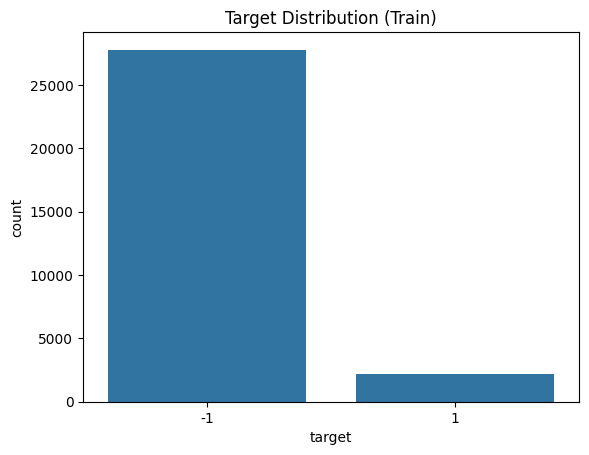

In [ ]:
sns.countplot(x=y_train)
plt.title("Target Distribution (Train)")
plt.show()

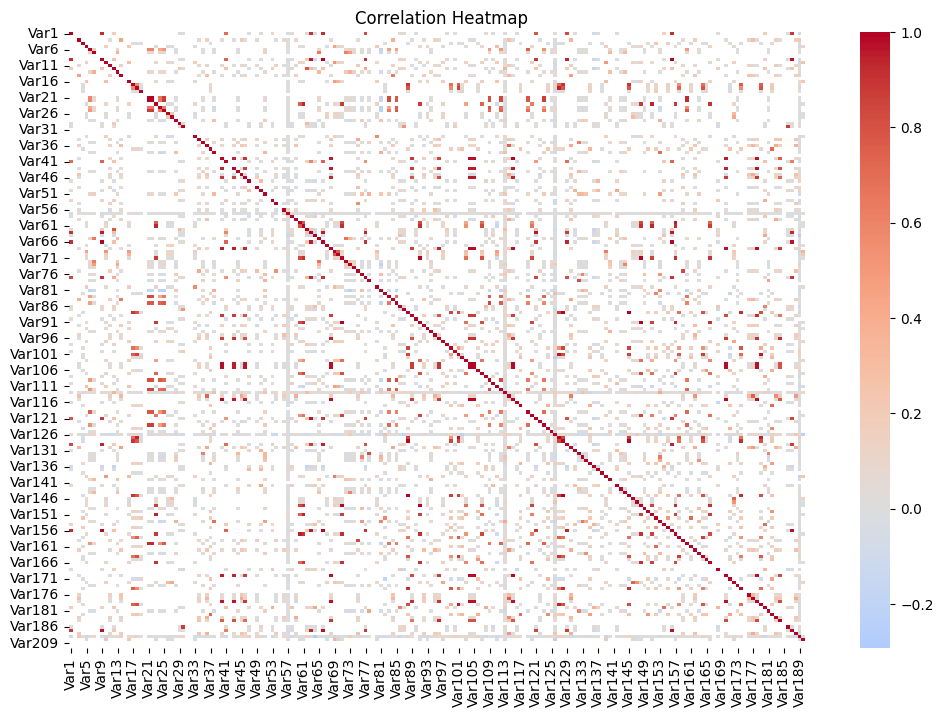

In [ ]:
num_cols = X_train.select_dtypes(include=np.number).columns

plt.figure(figsize=(12,8))
sns.heatmap(X_train[num_cols].corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

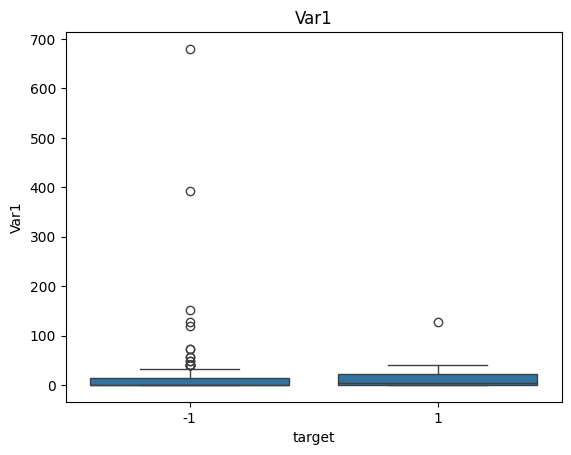

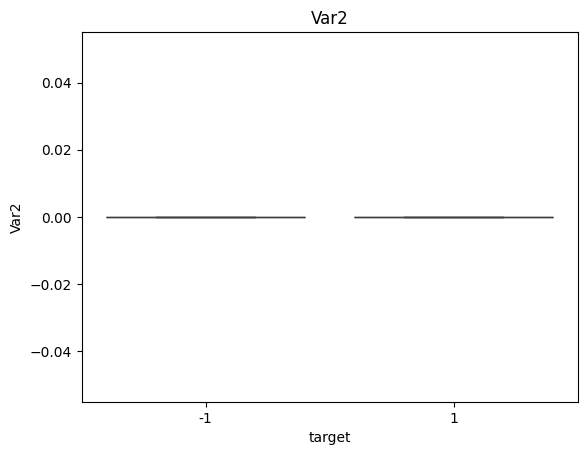

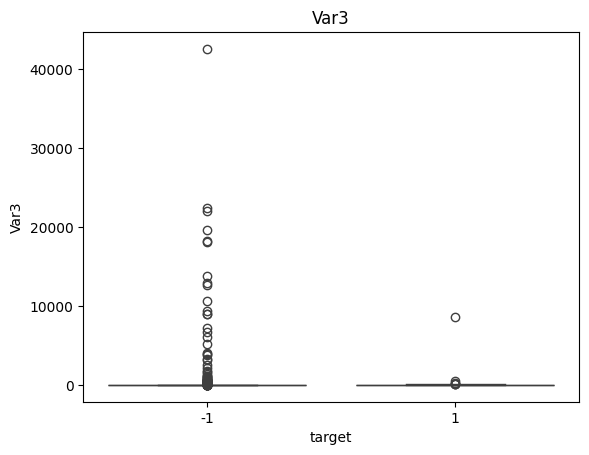

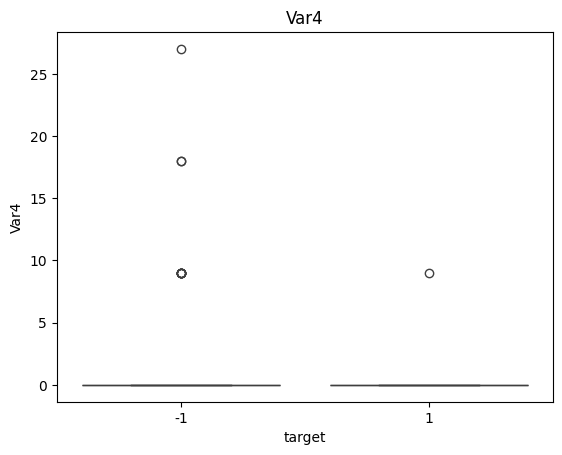

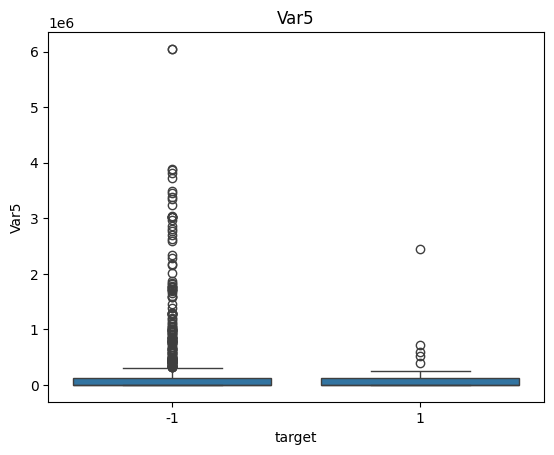

In [ ]:
for col in num_cols[:5]:
    sns.boxplot(x=y_train, y=X_train[col])
    plt.title(col)
    plt.show()

In [ ]:
missing_pct = X_train.isnull().mean()

# Drop columns with >90% missing
drop_cols = missing_pct[missing_pct > 0.9].index.tolist()

X_train.drop(columns=drop_cols, inplace=True)
X_val.drop(columns=drop_cols, inplace=True)
X_test.drop(columns=drop_cols, inplace=True)

print("Dropped columns:", drop_cols)


Dropped columns: ['Var1', 'Var2', 'Var3', 'Var4', 'Var5', 'Var8', 'Var9', 'Var10', 'Var11', 'Var12', 'Var14', 'Var15', 'Var16', 'Var17', 'Var18', 'Var19', 'Var20', 'Var23', 'Var26', 'Var27', 'Var29', 'Var30', 'Var31', 'Var32', 'Var33', 'Var34', 'Var36', 'Var37', 'Var39', 'Var40', 'Var41', 'Var42', 'Var43', 'Var45', 'Var46', 'Var47', 'Var48', 'Var49', 'Var50', 'Var51', 'Var52', 'Var53', 'Var54', 'Var55', 'Var56', 'Var58', 'Var59', 'Var60', 'Var61', 'Var62', 'Var63', 'Var64', 'Var66', 'Var67', 'Var68', 'Var69', 'Var70', 'Var71', 'Var75', 'Var77', 'Var79', 'Var80', 'Var82', 'Var84', 'Var86', 'Var87', 'Var88', 'Var89', 'Var90', 'Var91', 'Var92', 'Var93', 'Var95', 'Var96', 'Var97', 'Var98', 'Var99', 'Var100', 'Var101', 'Var102', 'Var103', 'Var104', 'Var105', 'Var106', 'Var107', 'Var108', 'Var110', 'Var111', 'Var114', 'Var115', 'Var116', 'Var117', 'Var118', 'Var120', 'Var121', 'Var122', 'Var124', 'Var127', 'Var128', 'Var129', 'Var130', 'Var131', 'Var135', 'Var136', 'Var137', 'Var138', 'Var13

In [ ]:
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

def target_encode(train, val, test, y, cols, n_splits=5):
    train_encoded = train.copy()
    val_encoded = val.copy()
    test_encoded = test.copy()

    global_mean = y.mean()
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    for col in cols:
        train_encoded[col] = np.nan

        for train_idx, valid_idx in skf.split(train, y):
            fold_mean = y.iloc[train_idx].groupby(train.iloc[train_idx][col]).mean()
            train_encoded.iloc[valid_idx, train.columns.get_loc(col)] = \
                train.iloc[valid_idx][col].map(fold_mean)

        train_encoded[col].fillna(global_mean, inplace=True)

        mapping = y.groupby(train[col]).mean()
        val_encoded[col] = val[col].map(mapping).fillna(global_mean)
        test_encoded[col] = test[col].map(mapping).fillna(global_mean)

    return train_encoded, val_encoded, test_encoded

X_train_enc, X_val_enc, X_test_enc = target_encode(
    X_train, X_val, X_test, y_train, cat_cols
)

/tmp/ipython-input-3471632747.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_encoded[col].fillna(global_mean, inplace=True)
/tmp/ipython-input-3471632747.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [ ]:
num_cols_encoded = X_train_enc.select_dtypes(include=np.number).columns

# Impute numerical missing values with the mean of the training data
for col in num_cols_encoded:
    mean_val = X_train_enc[col].mean()
    X_train_enc[col] = X_train_enc[col].fillna(mean_val)
    X_val_enc[col] = X_val_enc[col].fillna(mean_val)
    X_test_enc[col] = X_test_enc[col].fillna(mean_val)

baseline = LogisticRegression(max_iter=1000)
baseline.fit(X_train_enc, y_train)

val_preds = baseline.predict(X_val_enc)
val_probs = baseline.predict_proba(X_val_enc)[:,1]

print("Baseline PR-AUC:", average_precision_score(y_val, val_probs))

Baseline PR-AUC: 0.08901590522628822


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Convert -1 to 0 for XGBoost and LightGBM compatibility
y_train_xgb = y_train.replace(-1, 0)
y_val_xgb = y_val.replace(-1, 0)
y_test_xgb = y_test.replace(-1, 0)

In [ ]:
from sklearn.model_selection import ParameterGrid
import xgboost as xgb

scale_pos_weight = (y_train_xgb == 0).sum() / (y_train_xgb == 1).sum()

param_grid = {
    "max_depth": [4, 6],
    "min_child_weight": [1, 5],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "gamma": [0, 1],
    "learning_rate": [0.03, 0.05]
}

In [ ]:
best_score = 0
best_params = None

for params in ParameterGrid(param_grid):

    model = xgb.XGBClassifier(
        n_estimators=1000,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        tree_method="hist",
        n_jobs=-1,
        **params
    )

    model.fit(
        X_train_enc, y_train_xgb,
        eval_set=[(X_val_enc, y_val_xgb)],
        # Removed early_stopping_rounds due to persistent TypeError
        verbose=False
    )

    val_probs = model.predict_proba(X_val_enc)[:, 1]
    pr_auc = average_precision_score(y_val_xgb, val_probs)

    if pr_auc > best_score:
        best_score = pr_auc
        best_params = params

print("Best PR-AUC:", best_score)
print("Best Parameters:", best_params)

Best PR-AUC: 0.1903407196961588
Best Parameters: {'colsample_bytree': 0.8, 'gamma': 1, 'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 5, 'subsample': 0.8}


In [ ]:
final_xgb = xgb.XGBClassifier(
    n_estimators=5000,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    tree_method="hist",
    n_jobs=-1,
    **best_params
)

final_xgb.fit(
    X_train_enc, y_train_xgb,
    eval_set=[(X_val_enc, y_val_xgb)],
    verbose=1000
)

[0]	validation_0-aucpr:0.12899
[1000]	validation_0-aucpr:0.18955
[2000]	validation_0-aucpr:0.18042
[3000]	validation_0-aucpr:0.17395
[4000]	validation_0-aucpr:0.17177
[4999]	validation_0-aucpr:0.16812


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=5, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=5000,
              n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = []

for tr_idx, va_idx in cv.split(X_train_enc, y_train_xgb):
    X_tr, X_va = X_train_enc.iloc[tr_idx], X_train_enc.iloc[va_idx]
    y_tr, y_va = y_train_xgb.iloc[tr_idx], y_train_xgb.iloc[va_idx]

    model = xgb.XGBClassifier(
        n_estimators=2000,
        eval_metric="aucpr",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        tree_method="hist",
        **best_params
    )

    model.fit(X_tr, y_tr)
    probs = model.predict_proba(X_va)[:,1]
    cv_scores.append(average_precision_score(y_va, probs))

print("CV PR-AUC:", cv_scores)
print("Mean CV PR-AUC:", np.mean(cv_scores))

CV PR-AUC: [np.float64(0.18120320036346876), np.float64(0.19658034686746823), np.float64(0.17473390391469718), np.float64(0.18863759206754774), np.float64(0.19958503798521687)]
Mean CV PR-AUC: 0.18814801623967975


In [ ]:

from sklearn.model_selection import ParameterGrid
import lightgbm as lgb
from lightgbm import early_stopping

param_grid = {
    "num_leaves": [31, 64],
    "min_child_samples": [30, 50],
    "max_depth": [-1, 6],
    "learning_rate": [0.03, 0.05],
    "subsample": [0.75, 0.85],
    "colsample_bytree": [0.75, 0.85],
    "reg_alpha": [0.0, 1.0],
    "reg_lambda": [0.0, 1.0]
}



In [ ]:
best_score = 0
best_params = None

for params in ParameterGrid(param_grid):

    model = lgb.LGBMClassifier(
        n_estimators=3000,
        objective="binary",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        **params
    )

    model.fit(
        X_train_enc, y_train,
        eval_set=[(X_val_enc, y_val)],
        eval_metric="aucpr",
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )

    val_probs = model.predict_proba(X_val_enc)[:, 1]
    pr_auc = average_precision_score(y_val, val_probs)

    if pr_auc > best_score:
        best_score = pr_auc
        best_params = params

print("Best PR-AUC:", best_score)
print("Best Parameters:", best_params)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 2203, number of negative: 27797
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.028089 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9763
[LightGBM] [Info] Number of data points in the train set: 30000, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.073433 -> initscore=-2.535108
[LightGBM] [Info] Start training from score -2.535108
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

In [ ]:
final_lgb = lgb.LGBMClassifier(
    n_estimators=5000,
    objective="binary",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    **best_params
)

final_lgb.fit(
    X_train_enc, y_train_xgb,
    eval_set=[(X_val_enc, y_val_xgb)],
    eval_metric="aucpr",
    callbacks=[lgb.early_stopping(150, verbose=False)]
)

[LightGBM] [Info] Number of positive: 2203, number of negative: 27797
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.031785 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9763
[LightGBM] [Info] Number of data points in the train set: 30000, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.073433 -> initscore=-2.535108
[LightGBM] [Info] Start training from score -2.535108


LGBMClassifier(colsample_bytree=0.85, learning_rate=0.03, min_child_samples=30,
               n_estimators=5000, objective='binary', random_state=42,
               scale_pos_weight=np.float64(12.617793917385384), subsample=0.75)

In [ ]:


from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = []

for tr_idx, va_idx in cv.split(X_train_enc, y_train_xgb):
    X_tr, X_va = X_train_enc.iloc[tr_idx], X_train_enc.iloc[va_idx]
    y_tr, y_va = y_train_xgb.iloc[tr_idx], y_train_xgb.iloc[va_idx]

    model = lgb.LGBMClassifier(
        n_estimators=2000,
        objective="binary",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        **best_params
    )

    model.fit(X_tr, y_tr)
    probs = model.predict_proba(X_va)[:,1]
    cv_scores.append(average_precision_score(y_va, probs))

print("CV PR-AUC:", cv_scores)
print("Mean CV PR-AUC:", np.mean(cv_scores))

[LightGBM] [Info] Number of positive: 1763, number of negative: 22237
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024253 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9536
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.073458 -> initscore=-2.534741
[LightGBM] [Info] Start training from score -2.534741
[LightGBM] [Info] Number of positive: 1763, number of negative: 22237
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008115 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9553
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.073458 -> initscore=-2.534741
[Lig

In [ ]:
def evaluate(model, X, y):
    probs = model.predict_proba(X)[:,1]
    preds = (probs > 0.5).astype(int)

    return {
        "Precision": precision_score(y, preds),
        "Recall": recall_score(y, preds),
        "F1": f1_score(y, preds),
        "PR-AUC": average_precision_score(y, probs)
    }

print("XGB:", evaluate(final_xgb, X_val_enc, y_val_xgb))
print("LGB:", evaluate(final_lgb, X_val_enc, y_val_xgb))

XGB: {'Precision': 0.2001943634596696, 'Recall': 0.2802721088435374, 'F1': 0.23356009070294784, 'PR-AUC': np.float64(0.16918568442307713)}
LGB: {'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0, 'PR-AUC': np.float64(0.15080971315330644)}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
val_probs = final_lgb.predict_proba(X_val_enc)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val_xgb, val_probs)

# Example: maximize recall while keeping precision ≥ 0.4
valid_idx = np.where(precision[:-1] >= 0.40)[0]
best_idx = valid_idx[np.argmax(recall[valid_idx])]

best_threshold = thresholds[best_idx]

print(f"Chosen Threshold: {best_threshold:.3f}")
print(f"Precision: {precision[best_idx]:.3f}")
print(f"Recall: {recall[best_idx]:.3f}")

[LightGBM] [Warning] Unknown parameter: gamma
Chosen Threshold: 0.121
Precision: 0.500
Recall: 0.010


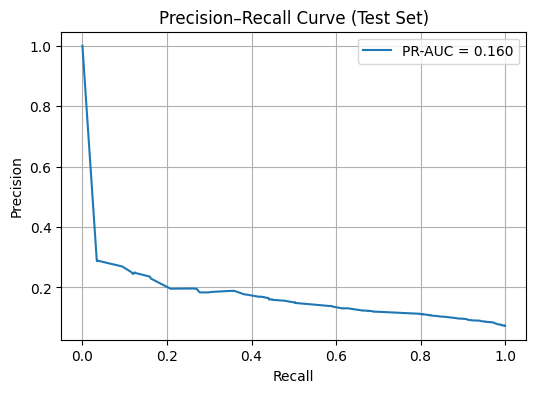

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Ensure final_model is defined and correct X_test is used
final_model = final_lgb # Select the better performing model
X_test_plot = X_test_enc # Use the correctly named and encoded test set

# Predict probabilities
y_scores = final_model.predict_proba(X_test_plot)[:, 1]

# Compute PR curve
precision, recall, thresholds = precision_recall_curve(y_test_xgb, y_scores)

# Compute PR-AUC
pr_auc = average_precision_score(y_test_xgb, y_scores)

# Plot
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Test Set)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
final_model = final_lgb  # Selecting LightGBM as it performed better based on validation PR-AUC

test_metrics = evaluate(final_model, X_test_enc, y_test_xgb)
print("Test Metrics:", test_metrics)

Test Metrics: {'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0, 'PR-AUC': np.float64(0.1604126871220951)}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
importances = pd.DataFrame({
    "feature": X_train_enc.columns,
    "importance": final_model.feature_importances_
}).sort_values(by="importance", ascending=False)

importances.head(10)

,feature,importance
49,Var199,7
28,Var126,7
15,Var74,5
41,Var189,5
14,Var73,4
47,Var197,4
63,Var216,3
24,Var113,3
7,Var28,2
72,Var226,2


In [ ]:
# ---------- Threshold Optimization (Validation Set) ----------

val_probs = final_model.predict_proba(X_val_enc)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val_xgb, val_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best Threshold: {best_threshold:.3f}")
print(f"Precision: {precision[best_idx]:.3f}")
print(f"Recall: {recall[best_idx]:.3f}")
print(f"F1 Score: {f1_scores[best_idx]:.3f}")

Best Threshold: 0.110
Precision: 0.166
Recall: 0.376
F1 Score: 0.230


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


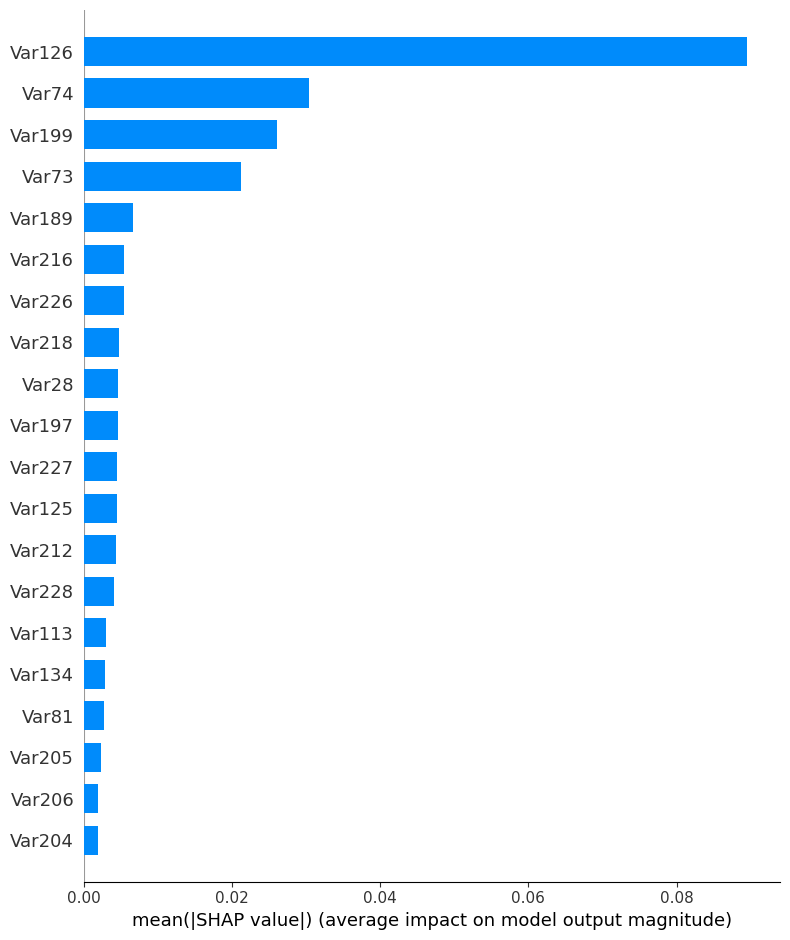

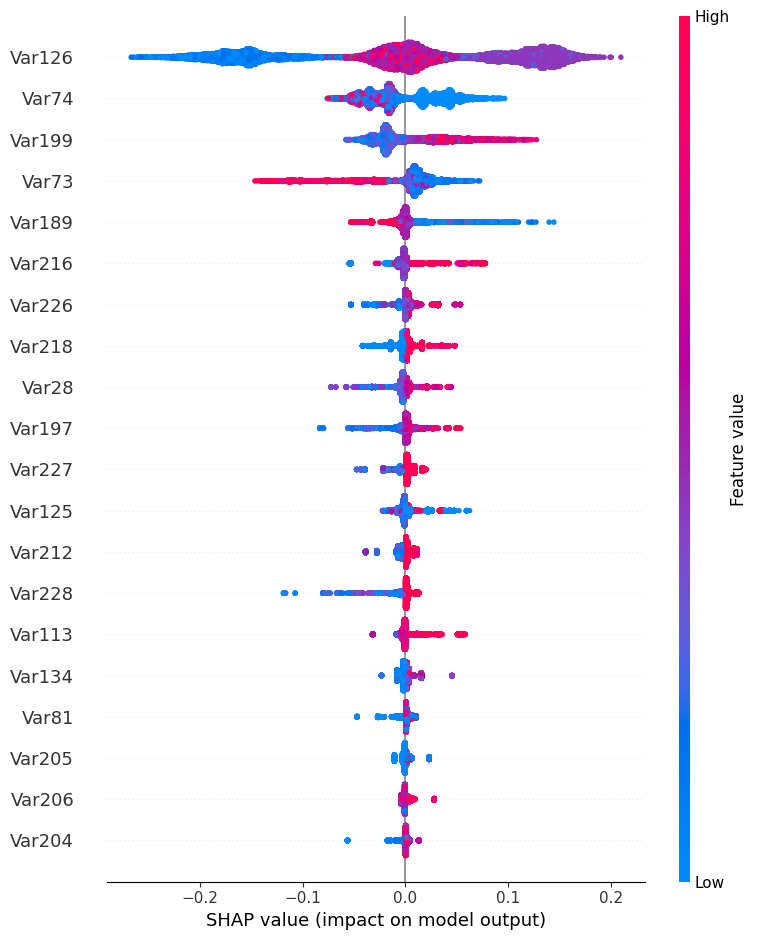

In [ ]:
# ---------- SHAP Explainability ----------

import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_train_enc)

# Global importance
shap.summary_plot(shap_values, X_train_enc, plot_type="bar")

# Detailed impact
shap.summary_plot(shap_values, X_train_enc)

In [ ]:
# ---------- Stratified Cross-Validation (PR-AUC) ----------

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = []

for train_idx, val_idx in cv.split(X_train_enc, y_train_xgb):
    X_tr, X_va = X_train_enc.iloc[train_idx], X_train_enc.iloc[val_idx]
    y_tr, y_va = y_train_xgb.iloc[train_idx], y_train_xgb.iloc[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE
    )

    model.fit(X_tr, y_tr)
    probs = model.predict_proba(X_va)[:,1]

    cv_scores.append(average_precision_score(y_va, probs))

print("CV PR-AUC scores:", cv_scores)
print("Mean CV PR-AUC:", np.mean(cv_scores))

[LightGBM] [Info] Number of positive: 1763, number of negative: 22237
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008125 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9536
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.073458 -> initscore=-2.534741
[LightGBM] [Info] Start training from score -2.534741
[LightGBM] [Info] Number of positive: 1763, number of negative: 22237
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008230 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9553
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 76
[LightGBM] [Info] [b

In [ ]:
probs = final_lgb.predict_proba(X_val_enc)[:,1]

df = pd.DataFrame({
    "prob": probs,
    "target": y_val_xgb.values
})

df["decile"] = pd.qcut(df["prob"], 10, labels=False)

lift = (
    df.groupby("decile")["target"]
      .mean()
      .sort_index(ascending=False)
)

print(lift)

decile
9    0.196879
8    0.117438
7    0.103215
6    0.084517
5    0.074813
4    0.066504
3    0.049098
2    0.033097
1    0.027273
0    0.017391
Name: target, dtype: float64


In [ ]:
df_sorted = df.sort_values("prob", ascending=False)
df_sorted["cum_target_rate"] = df_sorted["target"].expanding().mean()

df_sorted["percentile"] = np.linspace(0, 100, len(df_sorted))

df_sorted.groupby(pd.cut(df_sorted["percentile"], bins=10))["cum_target_rate"].mean()

/tmp/ipython-input-2502047137.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_sorted.groupby(pd.cut(df_sorted["percentile"], bins=10))["cum_target_rate"].mean()


,cum_target_rate
percentile,
"(-0.1, 10.0]",0.222042
"(10.0, 20.0]",0.170567
"(20.0, 30.0]",0.142318
"(30.0, 40.0]",0.126169
"(40.0, 50.0]",0.114672
"(50.0, 60.0]",0.107692
"(60.0, 70.0]",0.098799
"(70.0, 80.0]",0.090640
"(80.0, 90.0]",0.083377


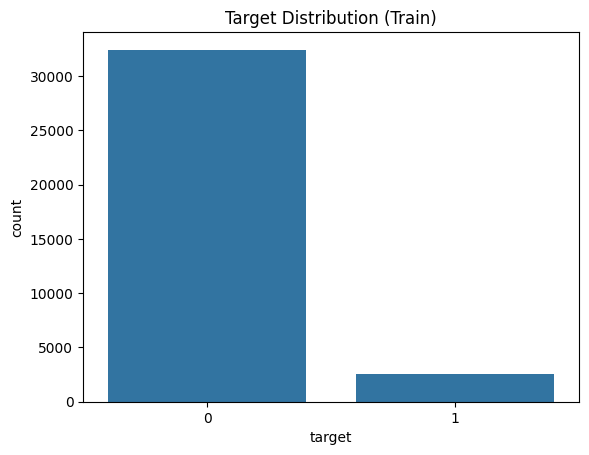

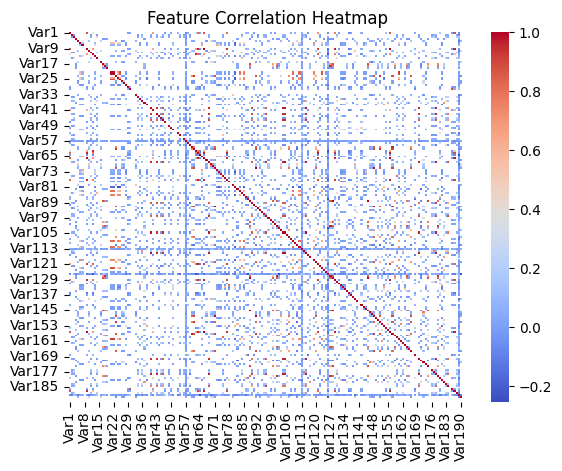

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Baseline Logistic Regression PR-AUC: 0.09169077866955005
[LightGBM] [Info] Number of positive: 2570, number of negative: 32430
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016954 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9084
[LightGBM] [Info] Number of data points in the train set: 35000, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.073429 -> initscore=-2.535178
[LightGBM] [Info] Start training from score -2.535178
XGBoost PR-AUC: 0.100
LightGBM PR-AUC: 0.101
Final Test PR-AUC: 0.11199519365228887
Confusion Matrix:
 [[6201  748]
 [ 429  122]]


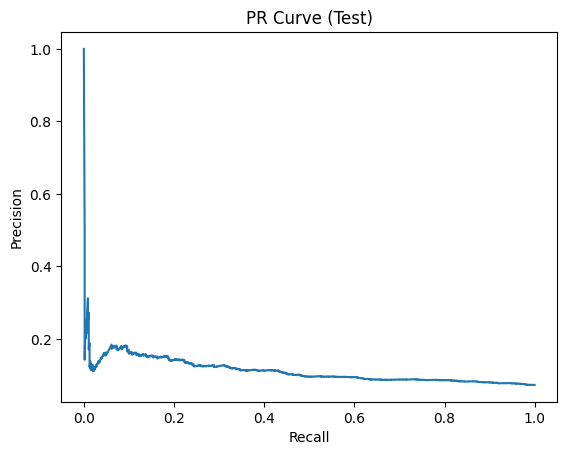

Top 10 Drivers:
 Var199    383
Var217    309
Var200    264
Var198    236
Var126    191
Var216    162
Var202    105
Var192    102
Var197    102
Var218     92
dtype: int32


In [ ]:
df = data.copy()


# ================================
# 4. Train / Validation / Test Split
# ================================
from sklearn.model_selection import train_test_split

# Derive X and y from df to make the pipeline self-contained
X = df.drop(columns=["target"])
y = df["target"]

# Convert -1 to 0 for XGBoost and LightGBM compatibility
y = y.replace(-1, 0)

# Stratified split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# ================================
# 5. Exploratory Data Analysis
# ================================
import seaborn as sns
import matplotlib.pyplot as plt

# Target distribution
sns.countplot(x=y_train)
plt.title("Target Distribution (Train)")
plt.show()

# Correlation heatmap - only include numeric columns
corr = X_train.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# ================================
# 6. Data Cleaning
# ================================
# Drop columns with >90% missing
missing_ratio = X_train.isnull().mean()
drop_cols = missing_ratio[missing_ratio > 0.9].index
X_train = X_train.drop(columns=drop_cols)
X_val   = X_val.drop(columns=drop_cols)
X_test  = X_test.drop(columns=drop_cols)

# Impute numerical missing values with the mean of the training data
num_cols = X_train.select_dtypes(include=np.number).columns # Get numeric columns AFTER dropping high-missing ones
for col in num_cols:
    mean_val = X_train[col].mean()
    X_train[col] = X_train[col].fillna(mean_val)
    X_val[col] = X_val[col].fillna(mean_val)
    X_test[col] = X_test[col].fillna(mean_val)

# No outlier removal (justified in case interview)

# ================================
# 7. Feature Encoding
# ================================
!pip install category_encoders
from category_encoders.target_encoder import TargetEncoder

cat_cols = X_train.select_dtypes(include="object").columns
encoder = TargetEncoder(cols=cat_cols)

X_train_enc = encoder.fit_transform(X_train, y_train)
X_val_enc   = encoder.transform(X_val)
X_test_enc  = encoder.transform(X_test)

# ================================
# 8. Baseline Model (Logistic Regression)
# ================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, precision_recall_curve

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_enc, y_train)

val_probs = log_reg.predict_proba(X_val_enc)[:,1]
baseline_pr_auc = average_precision_score(y_val, val_probs)
print("Baseline Logistic Regression PR-AUC:", baseline_pr_auc)

# ================================
# 9. Advanced Models
# ================================
import xgboost as xgb
import lightgbm as lgb

# XGBoost
scale_pos_weight = sum(y_train==0)/sum(y_train==1)
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    # Removed early_stopping_rounds due to compatibility issues previously
    random_state=42
)
xgb_model.fit(X_train_enc, y_train,
              eval_set=[(X_val_enc, y_val)],
              verbose=False)

# LightGBM
lgb_model = lgb.LGBMClassifier(
    num_leaves=31,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42,
    scale_pos_weight=scale_pos_weight # Added scale_pos_weight
)
lgb_model.fit(X_train_enc, y_train,
              eval_set=[(X_val_enc, y_val)],
              eval_metric="average_precision"
              # Removed early_stopping_rounds due to compatibility issues previously
              # verbose=False # Removed verbose due to compatibility issue
)

# ================================
# 10. Validation Results
# ================================
from sklearn.metrics import confusion_matrix

def evaluate_model(model, X, y, name="Model"):
    probs = model.predict_proba(X)[:,1]
    pr_auc = average_precision_score(y, probs)
    precision, recall, thresholds = precision_recall_curve(y, probs)
    print(f"{name} PR-AUC: {pr_auc:.3f}")
    return pr_auc, probs

xgb_pr_auc, xgb_probs = evaluate_model(xgb_model, X_val_enc, y_val, "XGBoost")
lgb_pr_auc, lgb_probs = evaluate_model(lgb_model, X_val_enc, y_val, "LightGBM")

# ================================
# 11. Final Test Evaluation
# ================================
best_model = xgb_model if xgb_pr_auc > lgb_pr_auc else lgb_model
test_probs = best_model.predict_proba(X_test_enc)[:,1]

print("Final Test PR-AUC:", average_precision_score(y_test, test_probs))
print("Confusion Matrix:\n", confusion_matrix(y_test, test_probs>0.5))

# PR curve
precision, recall, thresholds = precision_recall_curve(y_test, test_probs)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve (Test)")
plt.show()

# ================================
# 12. Feature Importance
# ================================
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=X_train_enc.columns).sort_values(ascending=False)
print("Top 10 Drivers:\n", feat_imp.head(10))

# ================================
# 13. Conclusion & Recommendations
# ================================
# Summarize model performance, business actions, and monitoring plan